# BEE 4750 Homework 3: Dissolved Oxygen and Monte Carlo

**Name**: Parker Catena, Regina Velasco

**ID**: pdc76, rv297

> **Due Date**
>
> Thursday, 10/16/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to implement a model for dissolved oxygen in a
    river with multiple waste releases and use this to develop a
    strategy to ensure regulatory compliance.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/BEE 4750/hw3-parker`


In [2]:
using Random
using Plots
using LaTeXStrings
using Distributions

## Problems (Total: 30 Points)

### Problem 1 (30 points)

A river which flows at 6 km/d is receiving waste discharges from two
sources which are 15 km apart. The oxygen reaeration rate is 0.55
day<sup>-1</sup>, and the decay rates of CBOD and NBOD are are 0.35 and
0.25 day<sup>-1</sup>, respectively. The river’s saturated dissolved
oxygen concentration is 10m g/L.

If the characteristics of the river inflow and waste discharges are
given in <a href="#tbl-river" class="quarto-xref">Table 1</a>, write a
Julia model to compute the dissolved oxygen concentration from the first
wastewater discharge to an arbitrary distance `d` km downstream. Use
your model to compute the minimum dissolved oxygen concentration up to
50 km downstream and how far downriver this maximum occurs.

| Parameter | River Inflow | Waste Stream 1 | Waste Stream 2 |
|:--:|---:|---:|---:|
| Inflow | 100,000 m<sup>3</sup>/d | 10,000 m<sup>3</sup>/d | 15,000 m<sup>3</sup>/d |
| DO Concentration | 7.5 mg/L | 5 mg/L | 5 mg/L |
| CBOD | 5 mg/L | 50 mg/L | 45 mg/L |
| NBOD | 5 mg/L | 35 mg/L | 35 mg/L |

Table 1: River inflow and waste stream characteristics for Problem 1.

$K_a = 0.55$ per day

$K_c = 0.35$ per day

$K_n = 0.25$ per day

$C_s = 10$ mg/L

### Problem 1.1

Implement the Streeter-Phelps (analytic) solution for the dissolved
oxygen concentration. Plot the dissolved oxygen concentration from the
first waste stream to 50 km downriver. What is the minimum value in
mg/L?

Minimum DO = 3.756 mg/L at x = 22.35 km


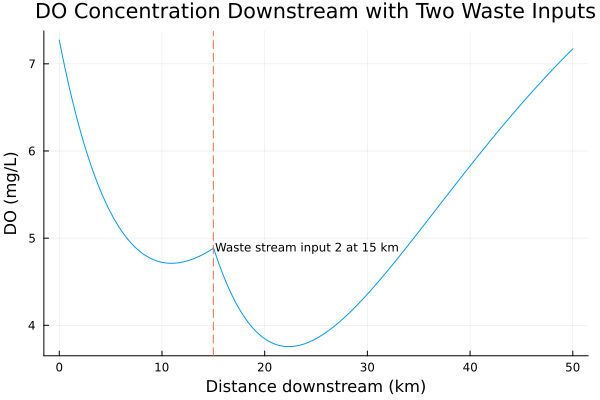

In [ ]:
u = 6 #km/day
dist = 15 #km
r = 0.55 #1/day
kc = 0.35 #1/day
kn = 0.25 #1/day
Cs = 10 #mg/L

Q_r0 = 100000 #m3/day
DO_r0 = 7.5 #mg/L
C_r0 = 5 #mg/L
N_r0 = 5 #mg/L

Q_w1 = 10000 #m3/day
DO_w1 = 5 #mg/L
C_w1 = 50 #mg/L
N_w1 = 35 #mg/L

Q_w2 = 15000 #m3/day
DO_w2 = 5 #mg/L
C_w2 = 45 #mg/L
N_w2 = 35 #mg/L

Q_out1 = Q_r0 + Q_w1 

function conc_initial(c0, q0, c1, q1, qout)
    ((c0*q0) + (c1*q1)) / qout
end

DO_out1 = conc_initial(DO_r0, Q_r0, DO_w1, Q_w1, Q_out1)
C_out1  = conc_initial(C_r0,  Q_r0, C_w1,  Q_w1, Q_out1)
N_out1  = conc_initial(N_r0,  Q_r0, N_w1,  Q_w1, Q_out1)

function conc(x, u, r, kc, kn, DO0, C0, N0, Cs)
    a1 = exp(-r*x/u)
    a2 = (kc/(r-kc))*(exp(-kc*x/u) - a1)
    a3 = (kn/(r-kn))*(exp(-kn*x/u) - a1)
    Cs*(1 - a1) + DO0*a1 - C0*a2 - N0*a3
end

#UNTIL X = 15 RIGHT BEFORE SECOND WASTE STREAM INPUT
x1 = range(0.0, stop=15.0, length=1501)           #<- use 0..15 here
C1 = conc.(x1, u, r, kc, kn, DO_out1, C_out1, N_out1, Cs)

#values at x=15
#(L0 and N0 were undefined; you meant the mixed CBOD/NBOD after the first discharge)
L15 = C_out1 * exp(-kc*15.0/u)                    #scalar math is fine
N15 = N_out1 * exp(-kn*15.0/u)
C15 = C1[end]                                     #indexing uses [end], not C1(end)

#SECOND WASTE STREAM INPUT AT X = 15 
Q_out2 = Q_out1 + Q_w2
DO_out2 = conc_initial(C15, Q_out1, DO_w2, Q_w2, Q_out2)
C_out2  = conc_initial(L15,  Q_out1, C_w2,  Q_w2, Q_out2)  
N_out2  = conc_initial(N15,  Q_out1, N_w2,  Q_w2, Q_out2)  

x2 = range(15.0, stop=50.0, length=3501)
C2 = conc.(x2 .- 15.0, u, r, kc, kn, DO_out2, C_out2, N_out2, Cs)

x_total = [x1; x2[2:end]]
C_total = [C1; C2[2:end]]
imin = argmin(C_total)
minDO = C_total[imin]
x_at_min = x_total[imin]
println("Minimum DO = $(round(minDO, digits=3)) mg/L at x = $(round(x_at_min, digits=3)) km")

#plot
plot(x_total, C_total, xlabel = "Distance downstream (km)", ylabel = "DO (mg/L)",
     title = "DO Concentration Downstream with Two Waste Inputs", legend = false)
vline!([15.0], linestyle = :dash)
annotate!(15.2, DO_out2, text("Waste stream input 2 at 15 km", :left, 8))




### Problem 1.2

Implement a numerically-integrated (discretized) solution for the
dissolved oxygen concentration. Using a resolution of 0.5km, conduct a
simulation and plot the results on the same axis as the plot from
Problem 1.1. How has the minimum value changed? What do you attribute
this difference to (be specific about the source of the difference(s) in
terms of the simulation dynamics, not just that one is a numerical
approximation).

**1.2 Solution**

Numerical min DO  = 3.658 mg/L at x = 22.5 km


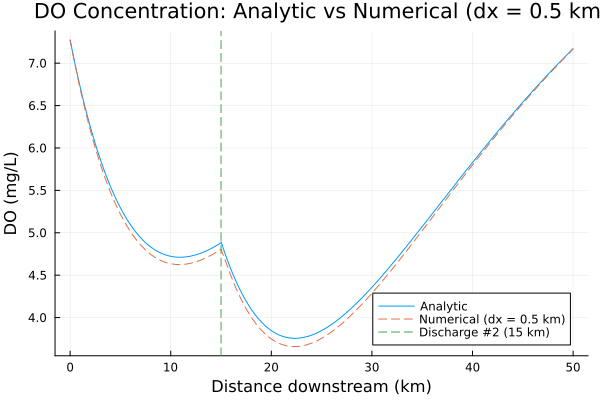

In [ ]:
dx = 0.5 #km
L = 50 #km

function do_numerical(L, dx, C0, B0, N0, ka, kn, kc, Cs, U) #Numerical implementation function from lecture
    n = Int(L / dx) #number of length steps
    C = zeros(n + 1)
    B = zeros(n + 1)
    N = zeros(n + 1)
    C[1] = C0
    B[1] = B0
    N[1] = N0
    for i = 1:n
        B[i+1] = B[i] * exp(-kc * dx / U)
        N[i+1] = N[i] * exp(-kn * dx / U)
        C[i+1] = C[i] + (dx / U) * (ka * (Cs - C[i]) - kc * B[i] - kn * N[i])
    end
    return (C, B, N)
end


#Right after first waste input
C1, B1, N1 = do_numerical(15.0, dx, DO_out1, C_out1, N_out1, r, kn, kc, Cs, u)

Q_out2 = Q_out1 + Q_w2
DO_15 = C1[end]
L_15 = B1[end] 
N_15 = N1[end]


DO_mix2 = conc_initial(DO_15, Q_out1, DO_w2, Q_w2, Q_out2)
L_mix2  = conc_initial(L_15,  Q_out1, C_w2,  Q_w2, Q_out2)
N_mix2  = conc_initial(N_15,  Q_out1, N_w2,  Q_w2, Q_out2)

#Right after second waste input
C2, B2, N2 = do_numerical(35.0, dx, DO_mix2, L_mix2, N_mix2, r, kn, kc, Cs, u)

x = [0.0:dx:15.0; 15.0+dx:dx:50.0]
DO_tot = [C1; C2[2:end]]

imin_num = argmin(DO_tot)
println("Numerical min DO  = $(round(DO_tot[imin_num], digits=3)) mg/L at x = $(round(x[imin_num], digits=3)) km")

#Plot DO conencentration: Analytic vs Numerical
if @isdefined(x_total) && @isdefined(C_total)
    plot(x_total, C_total, label="Analytic", xlabel="Distance downstream (km)", ylabel="DO (mg/L)",
         title="DO Concentration: Analytic vs Numerical (dx = 0.5 km)")
    plot!(x, DO_tot,linestyle=:dash, label="Numerical (dx = 0.5 km)")
    vline!([15.0], linestyle=:dash, label="Discharge #2 (15 km)")
else
    plot(x, DO_tot, label="Numerical (dx = 0.5 km)", xlabel="Distance downstream (km)", ylabel="DO (mg/L)",
         title="DO Concentration (Numerical, lecture scheme)")
    vline!([15.0], linestyle=:dash, label="Discharge #2 (15 km)")
end

**Explanation:**
Through the numerically-integrated solution the minimum value is 3.658 mg/L of DO at x = 22.5 km, compared to 3.756 mg/L of DO at x = 22.35 km using the analytical solution. So, the minimum value has decreased with the numerical solution. This could be because of numerical errors, such as truncation error. This is because the Euler method can over or under-estimate oxygen-defecit with each step depending on the line's curvature since the area under the curve is approximated as a rectangle. This causes the minimum to differ from the analytic solution.

### Problem 1.3

Using the analytic model, what is the minimum level of treatment (%
removal of organic waste; assume this is equivalent to the same level of
reduction of the CBOD and NBOD) for waste stream 1 that will ensure that
the dissolved oxygen concentration is in compliance with the 4 mg/L
standard along with a 5% margin of safety, assuming that waste stream 2
remains untreated? How about if only waste stream 2 is treated?

In [95]:
#Treat the first waste stream
#Intialize Relevant Variables
safe_fact = 0.05
do_min_target = (1 + safe_fact) * 4.0 
treat = 1.0 
step = 0.0001

#Helper to get analytic DO profile and its minimum for a given effective C_w1, N_w1
function treated_stream_1(Cw1_eff, Nw1_eff)

    #After first discharge (with treated stream 1)
    Q_out1 = Q_r0 + Q_w1
    DO_out1 = conc_initial(DO_r0, Q_r0, DO_w1, Q_w1, Q_out1)
    C_out1  = conc_initial(C_r0,  Q_r0, Cw1_eff, Q_w1, Q_out1)
    N_out1  = conc_initial(N_r0,  Q_r0, Nw1_eff, Q_w1, Q_out1)
    C1, B1, N1 = do_numerical(15.0, dx, DO_out1, C_out1, N_out1, r, kn, kc, Cs, u)

    #Right after first waste input
    L15 = C_out1 * exp(-kc*15.0/u)
    N15 = N_out1 * exp(-kn*15.0/u)
    C15 = C1[end]

    #Right after second waste input
    Q_out2 = Q_out1 + Q_w2
    DO_out2 = conc_initial(C15, Q_out1, DO_w2, Q_w2, Q_out2)
    C_out2  = conc_initial(L15,  Q_out1, C_w2,  Q_w2, Q_out2)
    N_out2  = conc_initial(N15,  Q_out1, N_w2,  Q_w2, Q_out2)
    C2, B2, N2 = do_numerical(35.0, dx, DO_out2, C_out2, N_out2, r, kn, kc, Cs, u)

    # Compute min value
    x = [0.0:dx:15.0; 15.0+dx:dx:50.0]
    DO_tot = [C1; C2[2:end]]
    idx = argmin(DO_tot)
    return DO_tot[idx], x[idx]
end

# Iterate treatment until min DO >= target 
minDO, xmin = treated_stream_1(treat * C_w1_0, treat * N_w1_0)

while (minDO < do_min_target)
    treat = max(0.0, treat - step)
    minDO, xmin = treated_stream_1(treat * C_w1_0, treat * N_w1_0)
end

println("Treatment for waste stream 1 to stay above $(do_min_target) mg/L:")
println("   $(round((1-treat)*100, digits=2))% removal")
println("   Minimum DO = $(round(minDO, digits=3)) mg/L at x = $(round(xmin, digits=2)) km")

#Treating second waste stream
#Reinitialize variables changed by first treatment
treat = 1.0 
C_w1 = 50 #mg/L
N_w1 = 35 #mg/L

#Helper to get analytic DO profile and its minimum for a given effective C_w2, N_w2
function treated_stream_2(Cw2_eff, Nw2_eff)

    #After first discharge
    Q_out1 = Q_r0 + Q_w1
    DO_out1 = conc_initial(DO_r0, Q_r0, DO_w1, Q_w1, Q_out1)
    C_out1  = conc_initial(C_r0,  Q_r0, C_w1,  Q_w1, Q_out1)
    N_out1  = conc_initial(N_r0,  Q_r0, N_w1,  Q_w1, Q_out1)
    C1, B1, N1 = do_numerical(15.0, dx, DO_out1, C_out1, N_out1, r, kn, kc, Cs, u)

    #Right after first waste input
    L15 = C_out1 * exp(-kc*15.0/u)
    N15 = N_out1 * exp(-kn*15.0/u)
    C15 = C1[end]

    #Right after second waste input
    Q_out2 = Q_out1 + Q_w2
    DO_out2 = conc_initial(C15, Q_out1, DO_w2,    Q_w2, Q_out2)
    C_out2  = conc_initial(L15, Q_out1, Cw2_eff,  Q_w2, Q_out2)
    N_out2  = conc_initial(N15, Q_out1, Nw2_eff,  Q_w2, Q_out2)
    C2, B2, N2 = do_numerical(35.0, dx, DO_out2, C_out2, N_out2, r, kn, kc, Cs, u)
    
    # Compute min value
    x = [0.0:dx:15.0; 15.0+dx:dx:50.0]
    DO_tot = [C1; C2[2:end]]
    idx = argmin(DO_tot)
    return DO_tot[idx], x[idx]
end

#Iterate treatment until min DO >= target
minDO, xmin = treated_stream_2(treat * C_w2, treat * N_w2)

while (minDO < do_min_target)
    treat = max(0.0, treat - step)
    minDO, xmin = treated_stream_2(treat * C_w2, treat * N_w2)
end

println("Treatment for waste stream 2 to stay above $(do_min_target) mg/L:")
println("   $(round((1-treat)*100, digits=2))% removal")
println("   min DO = $(round(minDO, digits=3)) mg/L at x = $(round(xmin, digits=2)) km")



Treatment for waste stream 1 to stay above 4.2 mg/L:
   33.14% removal
   Minimum DO = 4.2 mg/L at x = 23.0 km
Treatment for waste stream 2 to stay above 4.2 mg/L:
   26.14% removal
   min DO = 4.2 mg/L at x = 21.0 km


My code above for Problem 1.3 uses the code from Problems 1.1 and 1.2 to initialize the problem, and setup the original conditions. From there, I wrote a function for both the treated strean 1 and treated stream 2 which takes the conditions from problem 1.2 and only accepts the "treated" NBOD and CBOD as parameters. Using the numerical function, as well as the additional functions, we can then loop over each river to determine amount of treatment to bring the minimum level to be above 4.2 mg/L. I chose a step of 0.0001 for the treatment amount, starting from 1 (or no treatment), and subtracting the step each iteration. This allowed me to determine when the DO in the stream would exactly equal the minimum plus the safety factor (4.2 mg/L). Ultimately I found that solely treating waste stream 1 requires at least 33.14% treatment to stay above the 4.2 mg/L of DO, while only treating waste stream 2 would require 26.14% removal.

### Problem 1.4

Suppose you are responsible for designing a waste treatment plan for
discharges into the river, with a regulatory mandate to keep the
dissolved oxygen concentration above 4 mg/L. Discuss whether you’d opt
to treat waste stream 2 alone or both waste streams equally. What other
information might you need to make a conclusion, if any?

In order to best determine whether to only treat waste stream 2 or treat both streams equally, we would first need to understand the feasibility and costs associated with reducing the NBOD and CBOD in each stream. First we need to look at the level of treatment, or waste reduction, that can be achieved. We know that to keep the river above the 4.2 mg/L, we need to remove 26.14% of the waste so we would first need to understand the available technology and look at whether this figure is achievable. It may be the case that we can only remove 10% of the waste effectively, in which case we would be required to treat both streams. Similarly, we need to understand the marginal cost of removing waste. If it is feasible to remove up to 15% of the total BOD at a reasonable cost but extremely expensive above that threshold, then it may be worth treating each stream equally in order to reduce costs. Lastly, we would want to look at each waste stream and understand the conditions of the effluent. For instance, we may want to determine if waste stream 2 a more simple to treat than waste stream 1 due to geographical or process-level factors. Ultimately, there are many factors to consider, and given what we know, we cannot make a determination on which stream to treat.

### Problem 1.5

Suppose that it is known that the DO concentrations at the river inflow
can vary according to a $\text{LogNormal}(2.0, 0.15)$ distribution.
Conduct a Monte Carlo simulation of the DO concentration in the river.
If you treat only waste stream 1 (based on your analysis from Problem
1.3), what is the expected probability and 95% confidence interval that
the river fails to comply with the regulatory standard of 4 mg/L? How
did you decide that your Monte Carlo sample size was sufficiently large?

In [122]:
#Set Seed
Random.seed!(1)

#Treatment variable and safety value from problem 1.3
treat = 0.6686000000000365
safe_fact = 0.05
do_min_target = (1 + safe_fact) * 4.0 

#Create Log Normal Distrubution of DO in river
samples = 10000
DO = rand(LogNormal(2, 0.15), samples)

#Loop over each river DO value and count violations
violations = 0
for DO_r0 in DO
    DO_out1 = conc_initial(DO_r0, Q_r0, DO_w1, Q_w1, Q_out1)
    C_out1  = conc_initial(C_r0,  Q_r0, treat * C_w1,  Q_w1, Q_out1)
    N_out1  = conc_initial(N_r0,  Q_r0, treat * N_w1,  Q_w1, Q_out1)

    C1, B1, N1 = do_numerical(15.0, dx, DO_out1, C_out1, N_out1, r, kn, kc, Cs, u)

    Q_out2 = Q_out1 + Q_w2
    DO_15 = C1[end]
    L_15 = B1[end] 
    N_15 = N1[end]


    DO_mix2 = conc_initial(DO_15, Q_out1, DO_w2, Q_w2, Q_out2)
    L_mix2  = conc_initial(L_15,  Q_out1, C_w2,  Q_w2, Q_out2)
    N_mix2  = conc_initial(N_15,  Q_out1, N_w2,  Q_w2, Q_out2)

    #Right after second waste input
    C2, B2, N2 = do_numerical(35.0, dx, DO_mix2, L_mix2, N_mix2, r, kn, kc, Cs, u)

    x = [0.0:dx:15.0; 15.0+dx:dx:50.0]
    DO_tot = [C1; C2[2:end]]

    if any(DO_tot .< do_min_target)
        violations = violations + 1
    end
end
p_vio = violations / samples * 100
println("Percentage of samples out of compliance = $(round(p_vio, digits=2))%")

Percentage of samples out of compliance = 52.91%


## References

List any external references consulted, including classmates.